In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install "numpy<2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 

In [ ]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 36.8 MB/s eta 0:00:00


In [ ]:
!pip install torchinfo

In [ ]:
%pip install torch torchvision timm

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D
from tensorflow.keras.layers import Activation, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array, load_img
from sklearn.datasets import load_files
import matplotlib.image as mpimg
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical


(225, 225, 3)


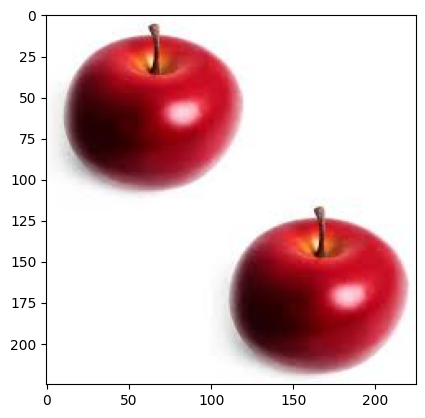

In [ ]:
img = mpimg.imread('/content/drive/MyDrive/deeplearning pj/test/Apple/Apple (1019).jpeg')
print(img.shape)
plt.imshow(img)

(147, 120, 3)


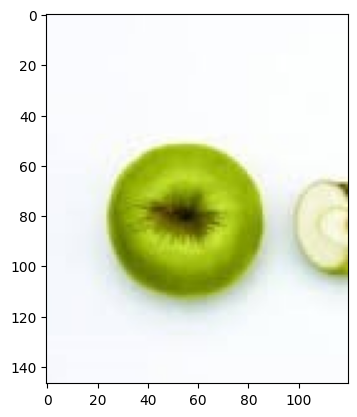

In [ ]:
img = mpimg.imread('/content/drive/MyDrive/deeplearning pj/train/Apple/Apple (1).jpeg')
print(img.shape)
plt.imshow(img)

(190, 265, 3)


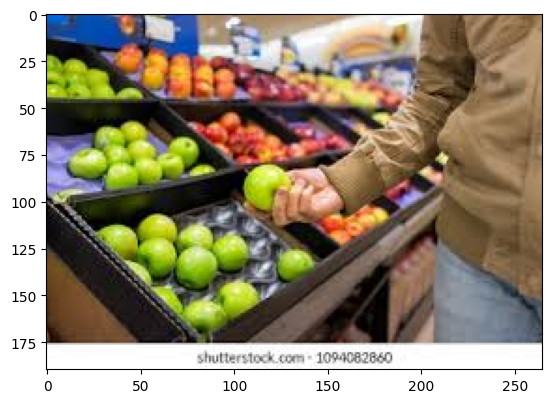

In [ ]:
img = mpimg.imread('/content/drive/MyDrive/deeplearning pj/valid/Apple/Apple (1034).jpeg')
print(img.shape)
plt.imshow(img)

In [ ]:
train_dir = '/content/drive/MyDrive/deeplearning pj/train'
test_dir = '/content/drive/MyDrive/deeplearning pj/test'
valid_dir = '/content/drive/MyDrive/deeplearning pj/valid'


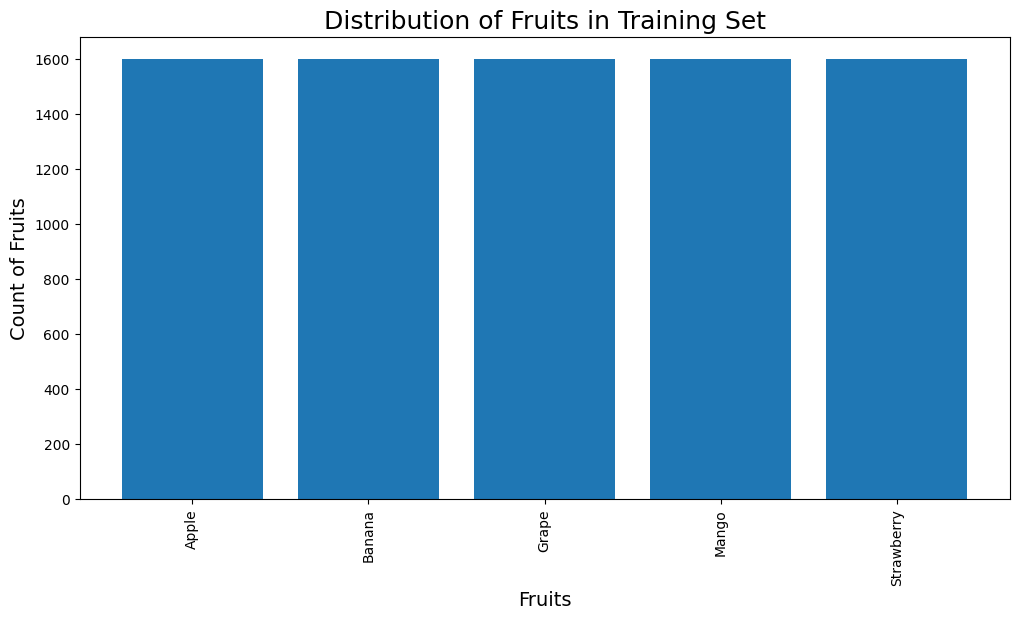

In [ ]:
import os

figure_size = plt.rcParams["figure.figsize"]
figure_size[0] = 12   # chiều rộng
figure_size[1] = 6    # chiều cao
plt.rcParams["figure.figsize"] = figure_size


# Get the categories (fruit names) and count samples
train_categories = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
train_samples = []

for category in train_categories:
    category_path = os.path.join(train_dir, category)
    num_images = len([name for name in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, name))])
    train_samples.append(num_images)

index = np.arange(len(train_categories))
plt.bar(index, train_samples)
plt.xlabel('Fruits', fontsize=14)
plt.ylabel('Count of Fruits', fontsize=14)
plt.xticks(index, train_categories, fontsize=10, rotation=90)
plt.title('Distribution of Fruits in Training Set', fontsize=18)
plt.show()

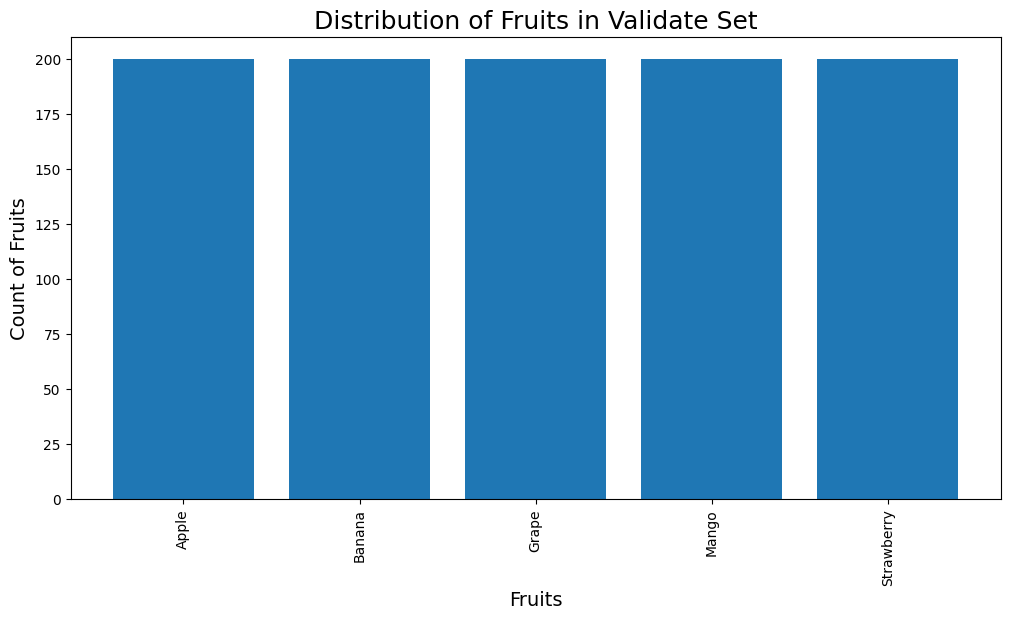

In [ ]:
import os

figure_size = plt.rcParams["figure.figsize"]
figure_size[0] = 12
figure_size[1] = 6
plt.rcParams["figure.figsize"] = figure_size

train_categories = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(valid_dir, d))])
train_samples = []

for category in train_categories:
    category_path = os.path.join(valid_dir, category)
    num_images = len([name for name in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, name))])
    train_samples.append(num_images)

index = np.arange(len(train_categories))
plt.bar(index, train_samples)
plt.xlabel('Fruits', fontsize=14)
plt.ylabel('Count of Fruits', fontsize=14)
plt.xticks(index, train_categories, fontsize=10, rotation=90)
plt.title('Distribution of Fruits in Validate Set', fontsize=18)
plt.show()

# preprocessing



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Ví dụ dùng MobileNetV2


def custom_preprocessing(image):
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)


    image = tf.cast(image, tf.float32)
    return image / 255.0

# CẤU HÌNH IMAGE DATA GENERATOR
train_datagen = ImageDataGenerator(
    rotation_range=40,          # Xoay ảnh tới 40 độ (hoa quả hay bị xoay)
    width_shift_range=0.2,      # Dịch sang trái/phải
    height_shift_range=0.2,     # Dịch lên/xuống
    shear_range=0.1,            # Làm méo ảnh nhẹ
    zoom_range=0.2,             # Phóng to/thu nhỏ (giả lập khoảng cách camera)
    horizontal_flip=True,       # Lật ngang (Quả táo lật lại vẫn là quả táo)
    vertical_flip=True,         # Lật dọc (Chấp nhận được với hoa quả rời)
    fill_mode='nearest',        # Điền khuyết bằng màu lân cận (tự nhiên hơn màu đen/trắng)
    brightness_range=[0.8, 1.2], # Tăng giảm độ sáng 20%
    channel_shift_range=10.0,    # Thay đổi nhẹ tone màu (RGB shift)

    preprocessing_function=custom_preprocessing
)

# Valid và Test chỉ cần chuẩn hóa, KHÔNG tăng cường
valid_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_gen = valid_test_datagen.flow_from_directory(
    valid_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = valid_test_datagen.flow_from_directory(
    test_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [ ]:
import os
save_dir = '/content/drive/MyDrive/deeplearning pj'
CHECKPOINT_DIR = '/content/drive/MyDrive/deeplearning pj/checkpoint'
os.makedirs(save_dir, exist_ok=True)


In [ ]:
# Copy data về local trên colab đọc cho nhanh
import shutil
import os

drive_data_path = '/content/drive/MyDrive/deeplearning pj'
# Đường dẫn trên máy ảo Colab
local_data_path = '/content/data_local'

if not os.path.exists(local_data_path):
    print("Đang copy dữ liệu từ Drive xuống máy ảo Colab để train nhanh hơn")
    shutil.copytree(drive_data_path, local_data_path)
    print("Copy xong")
else:
    print("Dữ liệu đã có sẵn trên máy ảo.")


Đang copy dữ liệu từ Drive xuống máy ảo Colab để train nhanh hơn (chỉ mất khoảng 1-2 phút)...
Copy xong! Bắt đầu train.


# KHởi tạo mô hình và tiền xử lý

In [ ]:
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

# --- CẤU HÌNH ---
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_EPOCHS = 40  # Đặt số lớn, EarlyStopping sẽ lo việc dừng
DATA_DIR = '/content/data_local/train' # Thay bằng đường dẫn ảnh thật của bạn trên Colab

# --- 1. CHUẨN BỊ DỮ LIỆU (DATA) ---
# (Giữ nguyên logic transform cũ vì nó tốt cho ViT)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(root='/content/data_local/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root='/content/data_local/valid', transform=val_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 2. ĐỊNH NGHĨA MODEL (LIGHTNING MODULE) ---
class ViTFruitClassifier(L.LightningModule):
    def __init__(self, num_classes, lr=1e-4):
        super().__init__()
        self.save_hyperparameters() # Tự động lưu các tham số (lr, num_classes)

        # Load Pre-trained ViT từ timm
        self.model = timm.create_model('vit_base_patch16_224', pretrained=True)

        # Thay đổi đầu ra (Head)
        self.model.head = nn.Linear(self.model.head.in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = 0

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        # Log loss để theo dõi (hiện trên thanh progress bar)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        # Tính accuracy đơn giản
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        # Quan trọng: Phải log "val_loss" để EarlyStopping theo dõi
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        # Tính toán độ chính xác
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        # Log lại với tên 'test_loss' và 'test_acc'
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)
        # Giảm LR khi loss không giảm nữa
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

# CẤU HÌNH CALLBACKS

#Early Stopping: Dừng nếu val_loss không giảm sau 5 epoch
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00,
    patience=5,
    verbose=True,
    mode="min"
)

# Model Checkpoint: Tự động lưu model vào Google Drive
checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename='vit',
    save_top_k=1,
    monitor="val_loss",
    mode="min",
    save_last=True
)

model = ViTFruitClassifier(num_classes=5)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

from torchinfo import summary

model = ViTFruitClassifier(num_classes=5)

summary(model, input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ViTFruitClassifier (ViTFruitClassifier)       [1, 3, 224, 224]     [1, 5]               --                   True
├─VisionTransformer (model)                   [1, 3, 224, 224]     [1, 5]               152,064              True
│    └─PatchEmbed (patch_embed)               [1, 3, 224, 224]     [1, 196, 768]        --                   True
│    │    └─Conv2d (proj)                     [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
│    │    └─Identity (norm)                   [1, 196, 768]        [1, 196, 768]        --                   --
│    └─Dropout (pos_drop)                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Identity (patch_drop)                  [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Identity (norm_pre)                    [1, 197, 768]        [1, 197, 768]        -

# Quá trình huấn luyện

In [ ]:
# Kiểm tra xem có file checkpoint 'last.ckpt' trên Drive không để tiếp tục
last_ckpt_path = os.path.join(CHECKPOINT_DIR, "last.ckpt")
resume_path = last_ckpt_path if os.path.exists(last_ckpt_path) else None

if resume_path:
    print(f"Load lại lần train trước {resume_path}")
else:
    print("Không có dữ liệu huấn luyện cũ. Bắt đầu train mới")

trainer = L.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="auto",
    devices=1,
    callbacks=[early_stop_callback, checkpoint_callback],
    default_root_dir=CHECKPOINT_DIR,
    enable_progress_bar=True
)
trainer.fit(model, train_loader, val_loader, ckpt_path=resume_path)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


==> KHÔNG TÌM THẤY CHECKPOINT. BẮT ĐẦU TRAIN MỚI.


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/deeplearning pj/checkpoint exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer │ 85.8 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 277                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 0.233
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.233
INFO: Metric val_loss improved by 0.015 >= min_delta = 0.0. New best score: 0.218
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.015 >= min_delta = 0.0. New best score: 0.218
INFO: Metric val_loss improved by 0.074 >= min_delta = 0.0. New best score: 0.143
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.074 >= min_delta = 0.0. New best score: 0.143
INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 0.143. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.143. Signaling Trainer to stop.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import lightning as L

TEST_DIR = '/content/data_local/train'
BATCH_SIZE = 16
CKPT_PATH = '/content/drive/MyDrive/deeplearning pj/checkpoint/vit.ckpt'

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

try:
    test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=1)
    print(f"Đã tìm thấy {len(test_dataset)} ảnh trong tập Test.")
except Exception as e:
    print(f"Lỗi không tìm thấy thư mục test hoặc cấu trúc sai. ({e})")


model = ViTFruitClassifier.load_from_checkpoint(CKPT_PATH)
model.eval()

print("Đánh giá độ chính xác trên toàn bộ tập Test")
trainer = L.Trainer(accelerator="auto", devices=1, logger=False)
trainer.test(model, dataloaders=test_loader)

Đã tìm thấy 8000 ảnh trong tập Test.


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Đánh giá độ chính xác trên toàn bộ tập Test


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9903749823570251     │
│         test_loss         │    0.03183653578162193    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.03183653578162193, 'test_acc': 0.9903749823570251}]

Đang chạy dự đoán trên toàn bộ tập test để vẽ ma trận...
Đang xử lý batch: 250/250 (100.0%)
Hoàn thành dự đoán!


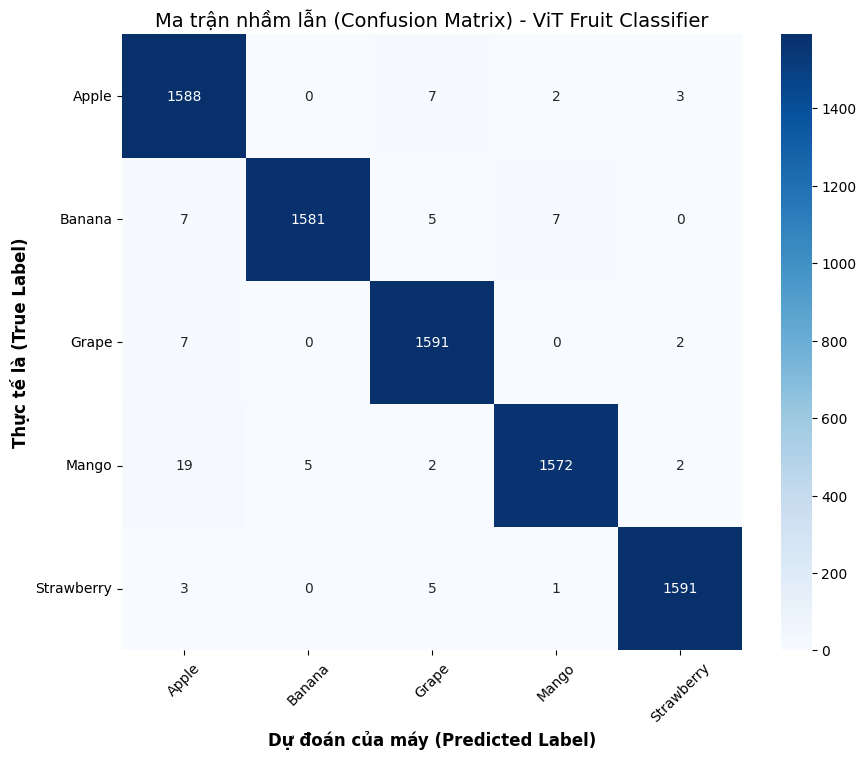

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import sys

y_true = []
y_pred = []

print("Đang chạy dự đoán trên toàn bộ tập test để vẽ ma trận...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_loader_full = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

total_batches = len(test_loader_full)

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader_full):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == total_batches:
            percent = (batch_idx + 1) / total_batches * 100
            sys.stdout.write(f"\rĐang xử lý batch: {batch_idx + 1}/{total_batches} ({percent:.1f}%)")
            sys.stdout.flush()

print("\nHoàn thành dự đoán!")

class_names = test_dataset.classes

# Tính confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ bằng Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Dự đoán của máy (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('Thực tế là (True Label)', fontsize=12, fontweight='bold')
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - ViT Fruit Classifier', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import lightning as L
import timm
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms


TEST_DIR = '/content/data_local/test'
BATCH_SIZE = 16
CKPT_PATH = '/content/drive/MyDrive/deeplearning pj/checkpoint/vit.ckpt'

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

try:
    test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=1)
    print(f"Đã tìm thấy {len(test_dataset)} ảnh trong tập Test.")
except Exception as e:
    print(f"Lỗi không tìm thấy thư mục test hoặc cấu trúc sai. ({e})")


model = ViTFruitClassifier.load_from_checkpoint(CKPT_PATH)
model.eval() # Chuyển sang chế độ đánh giá

print("Đánh giá độ chính xác trên toàn bộ tập Test")
trainer = L.Trainer(accelerator="auto", devices=1, logger=False)
trainer.test(model, dataloaders=test_loader)

Đã tìm thấy 1000 ảnh trong tập Test.


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Đánh giá độ chính xác trên toàn bộ tập Test


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9459999799728394     │
│         test_loss         │    0.16978247463703156    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.16978247463703156, 'test_acc': 0.9459999799728394}]

In [ ]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

log_base_dir = "/content/drive/MyDrive/deeplearning pj/checkpoint/lightning_logs"
if not os.path.exists(log_base_dir):
    print("Không tìm thấy thư mục log!")
else:
    versions = sorted([v for v in os.listdir(log_base_dir) if v.startswith("version")])
    last_version = versions[-1]
    log_dir = os.path.join(log_base_dir, last_version)

    print(f"Đang đọc dữ liệu từ: {log_dir}")


    event_file = [f for f in os.listdir(log_dir) if "events" in f][0]
    ea = EventAccumulator(os.path.join(log_dir, event_file))
    ea.Reload()


    available_tags = ea.Tags()['scalars']
    print("Các dữ liệu tìm thấy:", available_tags)

    if 'train_loss' in available_tags:
        print("\n=== LỊCH SỬ TRAIN LOSS ===")
        events = ea.Scalars('train_accuracy')
        for event in events:
            print(f"Step/Epoch {event.step}: {event.value:.4f}")
    else:
        print("Không tìm thấy tag 'train_loss'. Hãy kiểm tra lại tên trong danh sách tags trên.")

Đang đọc dữ liệu từ: /content/drive/MyDrive/deeplearning pj/checkpoint/lightning_logs/version_3
Các dữ liệu tìm thấy: ['hp_metric', 'val_loss', 'val_acc', 'epoch', 'train_loss']

=== LỊCH SỬ TRAIN LOSS ===
Step/Epoch 249: 0.3123
Step/Epoch 499: 0.1551
Step/Epoch 749: 0.1484
Step/Epoch 999: 0.1285
Step/Epoch 1249: 0.0994
Step/Epoch 1499: 0.1036
Step/Epoch 1749: 0.0871
Step/Epoch 1999: 0.0819
Step/Epoch 2249: 0.0177
Step/Epoch 2499: 0.0067
